# Take-home Assessment: TripPicks Media Optimization

---

### Background

Imagine, instead of PrizePicks, you are starting a new role at *Trip*Picks, a travel app that helps people find and book hotels at the right price.  TripPicks grows through a combination of organic demand and paid media, and understanding the drivers of that growth is a top analytical priority.

You're a data scientist on the Marketing Analytics team.  You've been handed a dataset of weekly marketing spend and account signups covering four years of TripPicks history (2021–2024).

---

### About the Exercise

The task is straightforward: **evaluate a channel reallocation proposal from marketing leadership, and give them a recommendation.**

| | |
|---|---|
| **Suggested Time** | 3-4 hours |
| **Deliverable** | This notebook, completed, submitted as `firstname_lastname_trippicks_case_study.ipynb` |
| **Follow-up** | 60 min interview, with dedicated 30 mins of live debrief - we'll ask you to walk through your thinking, and will further explore the problem together |

Approach this the way you'd approach a real problem on your first week here: start with the data, find what's interesting, and build toward a recommendation.  Note the suggested time: we are not looking for a perfect model here.  Instead, what we most care about is:

- **What you notice.** In this exercise, good EDA is more valuable than a complex model.  We want to see how you approach a data set.
- **How you handle uncertainty.** There are things this data can and can't tell you.  We want to see you reason about the limits of your analysis. When in doubt, state your assumptions and flag your concerns.
- **Whether you can deliver clear, actionable recommendations.** Despite uncertainty, the stakeholders still need guidance.  We want to see you be able to navigate the ambiguity, and push the business toward a more optimal outcome.

---

### Dataset - `trippicks_case_data.csv`

| Column | Description |
|--------|-------------|
| `week` | Week start date (Monday) |
| `signups` | New account signups that week - your primary KPI |
| `paid_social_spend` | Paid social spend (USD) |
| `affiliate_spend` | Affiliate / influencer spend (USD) |
| `market_expansion_index` | Normalized index (0–1) reflecting TripPicks' available market size over time, as they've expanded into new cities and regions |
| `summer_peak` | 1 if week falls within summer travel season (Jun–Aug), else 0 |
| `holiday_peak` | 1 if week falls within holiday travel season (Nov–Dec), else 0 |
| `shoulder_season` | 1 if week falls within fall shoulder season (Sep–Oct), else 0 |

---

## Part 1 - Explore the data

This is where you showcase how you get oriented with a dataset. Work through some exploratory data analysis (EDA). Make sure to note down patterns, anomalies, and/or questions that jump out at you. You will include these in the findings cell at the bottom of this section.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./trippicks_case_data.csv', parse_dates=['week'])
df.head()

,week,signups,paid_social_spend,affiliate_spend,market_expansion_index,summer_peak,holiday_peak,shoulder_season
0,2021-01-04,3633,313352,40340,0.0,0,0,0
1,2021-01-11,3671,298560,46325,0.0,0,0,0
2,2021-01-18,3474,318255,60075,0.0,0,0,0
3,2021-01-25,3711,320346,35410,0.0,0,0,0
4,2021-02-01,3418,288539,50337,0.0,0,0,0


In [3]:
# Your EDA here. Feel free to break up into multiple cells within this section
media_spend = ['paid_social_spend','affiliate_spend']
print('shape of data: ',df.shape)
print('data info: ',df.info())
print('data description: ',df.describe())

shape of data:  (208, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   week                    208 non-null    datetime64[ns]
 1   signups                 208 non-null    int64         
 2   paid_social_spend       208 non-null    int64         
 3   affiliate_spend         208 non-null    int64         
 4   market_expansion_index  208 non-null    float64       
 5   summer_peak             208 non-null    int64         
 6   holiday_peak            208 non-null    int64         
 7   shoulder_season         208 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6)
memory usage: 13.1 KB
data info:  None
data description:                        week       signups  paid_social_spend  affiliate_spend  \
count                  208    208.000000         208.000000       208.000000   
mean 

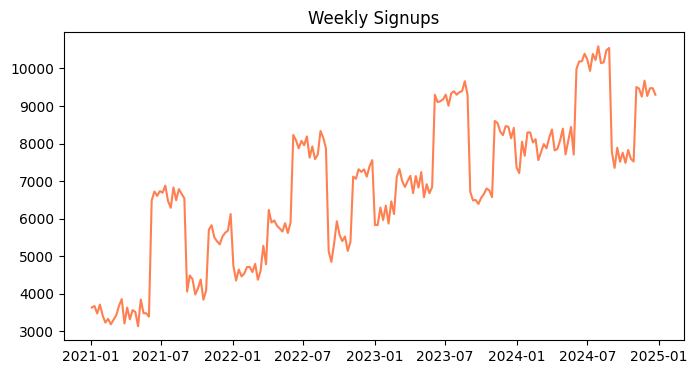

In [4]:
import matplotlib.pyplot as plt
# target plot
plt.figure(figsize=(8,4))
plt.plot(df['week'],df['signups'],color='coral')
plt.title('Weekly Signups')
plt.show()

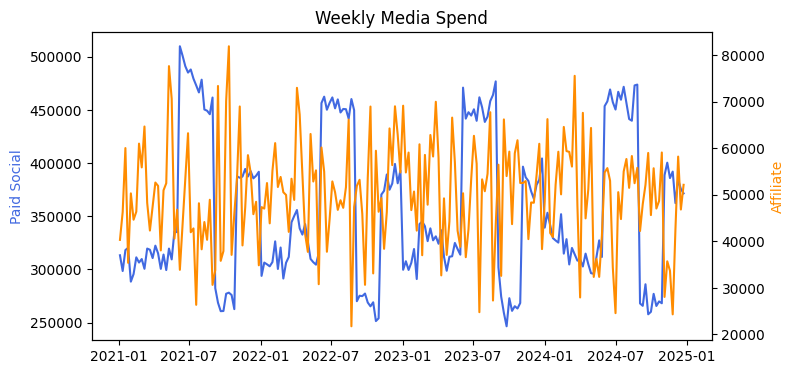

In [5]:
# media spend
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(df['week'],df['paid_social_spend'],color='royalblue',label='paid_social_spend')
ax1.set_ylabel('Paid Social',color='royalblue')
ax2 = ax1.twinx()
ax2.plot(df['week'],df['affiliate_spend'],color='darkorange',label='affiliate_spend')
ax2.set_ylabel('Affiliate',color='darkorange')
plt.title('Weekly Media Spend')
plt.show()

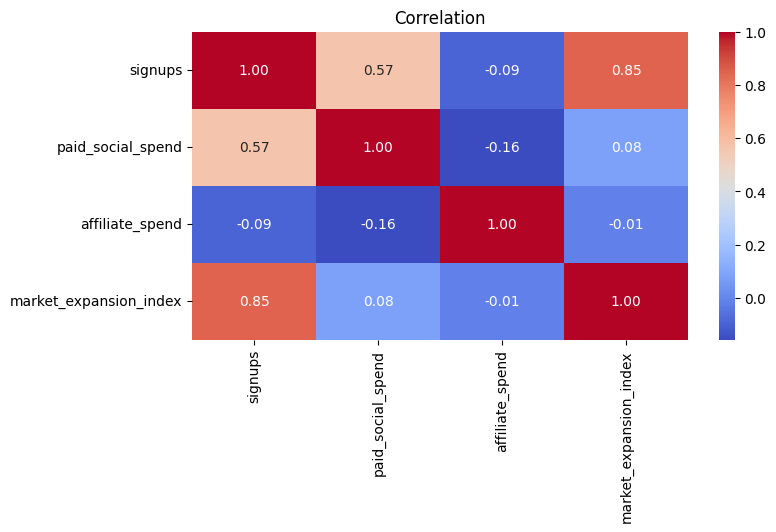

In [6]:
# correlation
import seaborn as sns
corr_cols = ['signups','paid_social_spend','affiliate_spend','market_expansion_index']
corr = df[corr_cols].corr()
plt.figure(figsize=(8,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation')
plt.show()

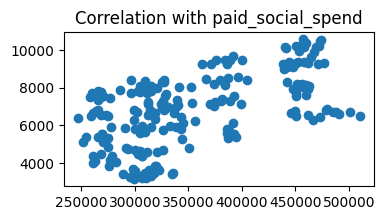

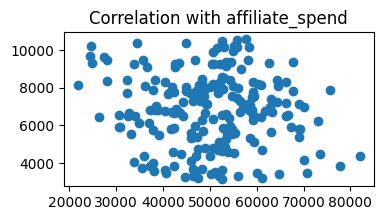

In [7]:
# correlation with targe
for col in media_spend:
    plt.figure(figsize=(4,2))
    plt.scatter(df[col],df['signups'])
    plt.title(f'Correlation with {col}')
    plt.show()

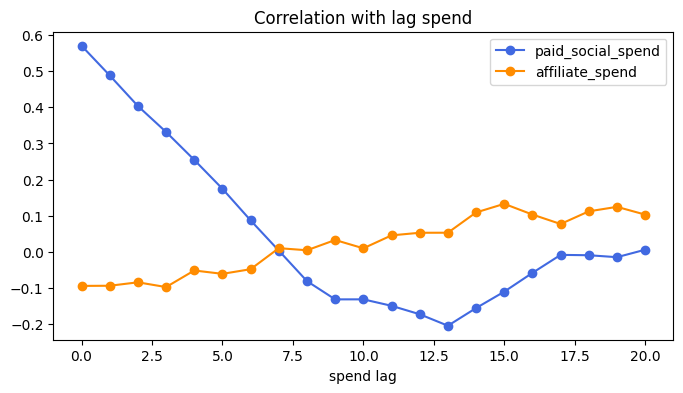

In [8]:
# lag anaysis
df = df.sort_values('week')
plt.figure(figsize=(8,4))
colors = ['royalblue','darkorange']
for col, color in zip(media_spend,colors):
    lag_corrs = []
    for lag in range(21):
        shifted = df[col].shift(lag)
        corr = shifted.corr(df['signups'])
        lag_corrs.append(corr)
    plt.plot(range(21),lag_corrs,label=col,color=color,marker='o')
plt.xlabel('spend lag')
plt.title('Correlation with lag spend')
plt.legend()
plt.show()

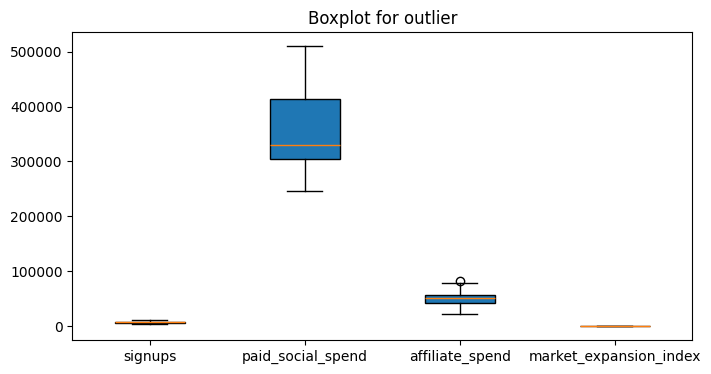

In [9]:
# boxplot for outliers
plt.figure(figsize=(8,4))
plt.boxplot([df[col].dropna() for col in corr_cols],labels=corr_cols,patch_artist=True)
plt.title('Boxplot for outlier')
plt.show()

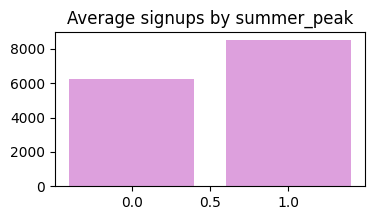

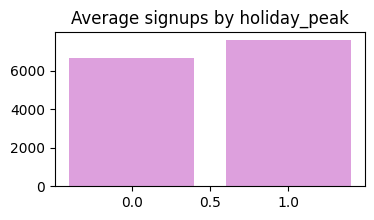

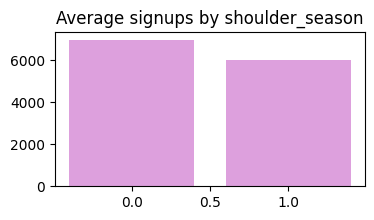

In [10]:
# seasonal analysis
season_cols = ['summer_peak','holiday_peak','shoulder_season']
for col in season_cols:
    group_df = df.groupby(col)['signups'].mean().reset_index()
    plt.figure(figsize=(4,2))
    plt.bar(group_df[col],group_df['signups'],color='plum')
    plt.title(f'Average signups by {col}')
    plt.show()

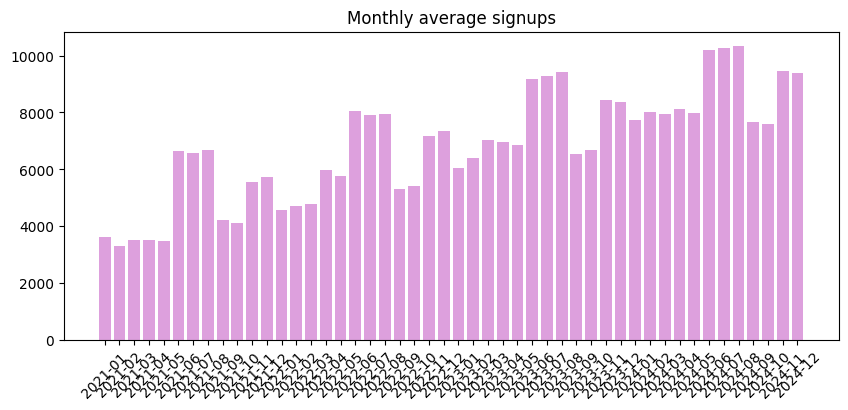

In [11]:
# monthly bar
df['month'] = df['week'].dt.to_period('M').astype(str)
group_df = df.groupby('month')['signups'].mean().reset_index()
plt.figure(figsize=(10,4))
plt.bar(group_df['month'],group_df['signups'],color='plum')
plt.title('Monthly average signups')
plt.xticks(rotation=45)
plt.show()

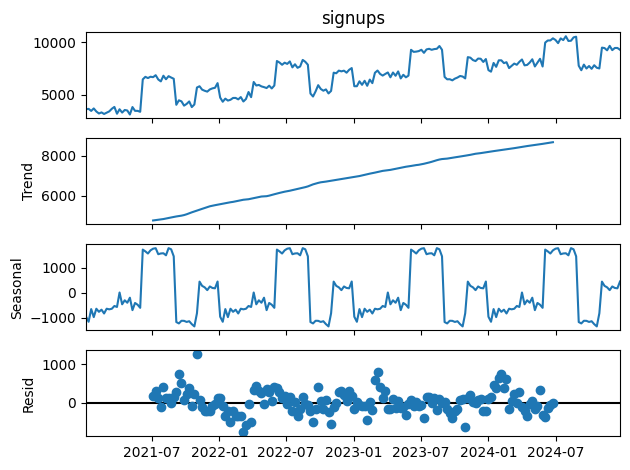

In [12]:
# time series
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(
    df.set_index('week')['signups'],
    model='additive',
    period=52
)
decomp.plot()
plt.show()

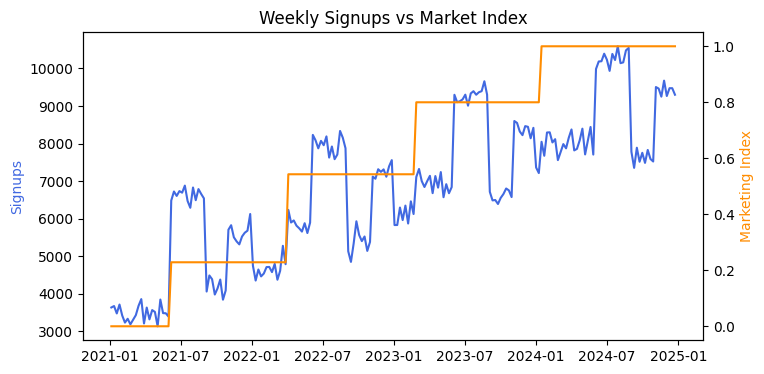

In [13]:
# market expansion
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(df['week'],df['signups'],color='royalblue',label='signups')
ax1.set_ylabel('Signups',color='royalblue')
ax2 = ax1.twinx()
ax2.plot(df['week'],df['market_expansion_index'],color='darkorange',label='market index')
ax2.set_ylabel('Marketing Index',color='darkorange')
plt.title('Weekly Signups vs Market Index')
plt.show()

**What you found - and what it implies:**

1. There are strong upward trend with clear seasonality peaks during June-August and November-December
2. Media spend remains relatively stable over time, indicating increasing CPI, and paid social spend shows seasonal patterns
3. Paid social spend shows a positive correlation with signups and market_expansion_index appears to have even stronger relationship with signups
4. There is no strong multicollinearity observed between media channels
5. Affiliate spend contains outliers, while paid social spend shows long-tailed distribution
6. Paid social spend has the highest correlation with signups at period 0, suggesting it bahves as a fast-decay channel with an immediate response effect

---
## Part 2 - Evaluate the proposal

Marketing leadership has a proposal on the table: **cut affiliate spend by roughly 40%, and reinvest the savings into paid social.**

Their reasoning: they've noticed paid social spend has correlated much more strongly with signup volume in week-to-week reporting, and they are starting to believe the dollars will work harder there.

Your job is to evaluate that proposal rigorously. Decompose what's driving signups. Isolate the contribution of both channels as cleanly as the data allows. As you work through the analysis, note what you can and can't conclude from this dataset, and what you'd investigate further if you had more time.

Use whatever approach makes sense to you - there's no required framework. However, if in doubt, lean toward simplificity & explainability in your approach.

In [14]:
# consider staturation, adstock, standardize scaler
df['paid_social_sat'] = np.log1p(df['paid_social_spend'])
df['affiliate_sat'] = np.log1p(df['affiliate_spend'])
# standardize scale
from sklearn.preprocessing import StandardScaler
scale_cols = ["paid_social_spend","affiliate_spend","market_expansion_index"]
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_standard" for col in scale_cols],
    index=df.index
)
df = pd.concat([df, scaled_df], axis=1)

In [15]:
# fit a linear regression model
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
features = ["paid_social_spend_standard","affiliate_spend_standard","market_expansion_index_standard","summer_peak","holiday_peak","shoulder_season"]
# features = ["paid_social_spend","affiliate_spend","market_expansion_index","summer_peak","holiday_peak","shoulder_season"]
X = df[features]
y = df['signups']
X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
y_pred = model.predict(X)
residuals = y - y_pred
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    'feature': model.params.index,
    'coef': model.params.values
})
print('coef: ', coef_df)
print('r2: ', r2)
print('mae: ', mae)
print('rmse: ', rmse)

coef:                             feature         coef
0                            const  6254.751826
1       paid_social_spend_standard   194.847861
2         affiliate_spend_standard     0.424025
3  market_expansion_index_standard  1545.977719
4                      summer_peak  1740.943464
5                     holiday_peak  1085.928542
6                  shoulder_season  -330.002336
r2:  0.9868405263366878
mae:  176.06648502114575
rmse:  221.9798980647338


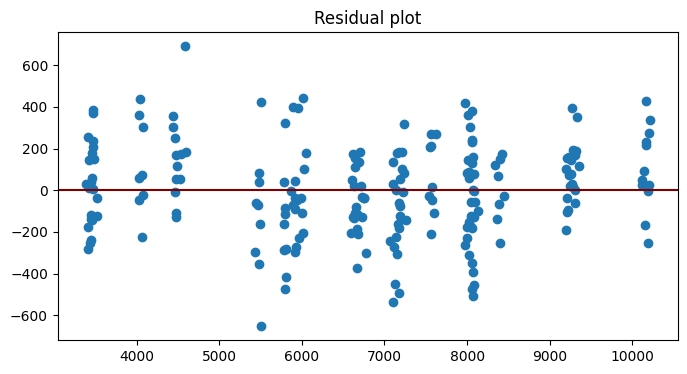

In [16]:
# residual plot
plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='maroon')
plt.title('Residual plot')
plt.show()

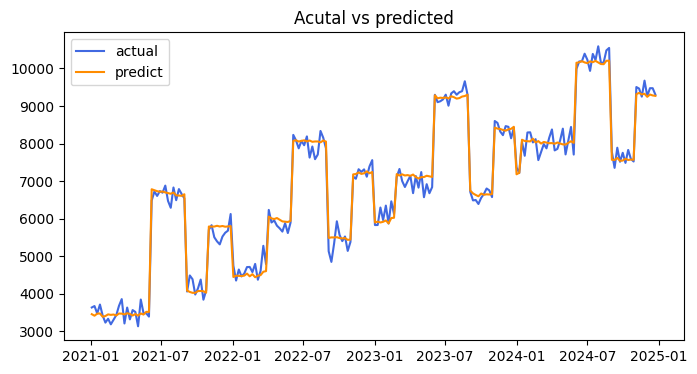

In [17]:
# actual vs predict
plt.figure(figsize=(8,4))
plot_df = pd.DataFrame({
    'week':df['week'],
    'actual':y,
    'predict':y_pred
})
plt.plot(plot_df['week'],plot_df['actual'],label='actual',color='royalblue')
plt.plot(plot_df['week'],plot_df['predict'],label='predict',color='darkorange')
plt.title('Acutal vs predicted')
plt.legend()
plt.show()

In [18]:
# contribution
contribute_df = pd.DataFrame(index=df.index)
coef_original = {}
# reverse back to original value
for i, col in enumerate(scale_cols):
    scaled_name = col + "_standard"
    coef_original[col] = (
        model.params[scaled_name]
        / scaler.scale_[i]
    )
intercept_original = model.params["const"]
for i, col in enumerate(scale_cols):
    scaled_name = col + "_standard"
    intercept_original -= (
        model.params[scaled_name] * scaler.mean_[i] / scaler.scale_[i]
    )
for col in scale_cols:
    contribute_df[col + "_contribute"] = df[col] * coef_original[col]
non_scaled_cols = [
    col for col in features
    if col not in [c + "_standard" for c in scale_cols]
]
for col in non_scaled_cols:
    contribute_df[col + "_contribute"] = df[col] * model.params[col]
# output result
contribute_df["baseline_contribute"] = intercept_original
contribute_df["predicted_signup"] = contribute_df.sum(axis=1)
contribute_df["actual_signup"] = df["signups"]
total_contribute = (
    contribute_df
    .sum()
    .sort_values(ascending=False)
).apply(lambda x: f"{x:,.0f}")
print(total_contribute)

predicted_signup                     1,415,803
actual_signup                        1,415,803
market_expansion_index_contribute      558,121
baseline_contribute                    538,149
paid_social_spend_contribute           204,323
summer_peak_contribute                  90,529
holiday_peak_contribute                 35,836
affiliate_spend_contribute                 395
shoulder_season_contribute             -11,550
dtype: object


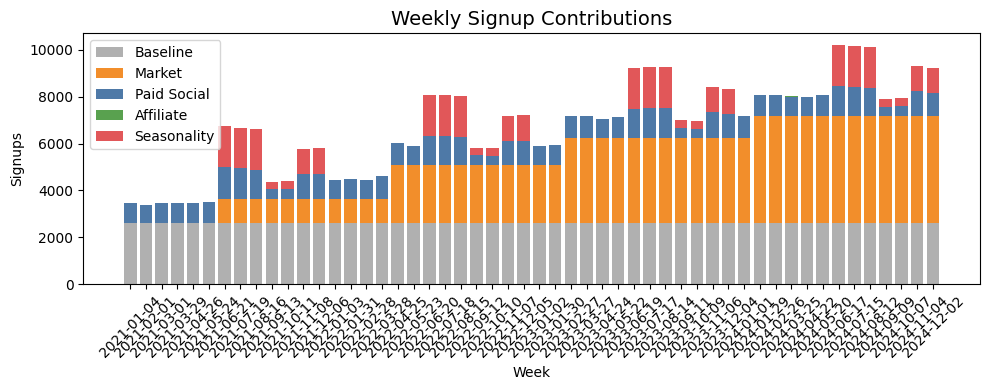

In [19]:
plot_df = pd.DataFrame({
    "week": df["week"],
    "baseline": contribute_df["baseline_contribute"],
    "market": contribute_df["market_expansion_index_contribute"],
    "paid_social": contribute_df["paid_social_spend_contribute"],
    "affiliate": contribute_df["affiliate_spend_contribute"],
})

seasonality_cols = [
    col + "_contribute"
    for col in ["summer_peak", "holiday_peak", "shoulder_season"]
    if col in features and col + "_contribute" in contribute_df.columns
]
plot_df["seasonality"] = contribute_df[seasonality_cols].sum(axis=1) if seasonality_cols else 0
plot_df = plot_df.sort_values("week").reset_index(drop=True)
plot_small = plot_df.iloc[::4].copy()
plt.figure(figsize=(10, 4))
bottom = np.zeros(len(plot_small))
colors = {
    "baseline": "#B0B0B0",
    "market": "#F28E2B",
    "paid_social": "#4E79A7",
    "affiliate": "#59A14F",
    "seasonality": "#E15759",
}
for col in ["baseline", "market", "paid_social", "affiliate", "seasonality"]:
    plt.bar(
        plot_small["week"].astype(str),
        plot_small[col],
        bottom=bottom,
        label=col.replace("_", " ").title(),
        color=colors[col]
    )
    bottom += plot_small[col].values
plt.title("Weekly Signup Contributions", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Signups")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# scenario: cut affiliate by 40% and reinvest to paid social
new_df = df.copy()
new_df['predicted_base'] = model.predict(X)
cut_affiliate = new_df['affiliate_spend'] * 0.4
new_df['affiliate_spend'] = new_df['affiliate_spend'] - cut_affiliate
new_df['paid_social_spend'] = new_df['paid_social_spend'] + cut_affiliate
scaled_values = scaler.transform(new_df[scale_cols])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + "_standard" for col in scale_cols],
    index=new_df.index
)
for col in scaled_df.columns:
    new_df[col] = scaled_df[col]
X_new = new_df[features]
X_new = sm.add_constant(X_new)
new_df['predicted_new'] = model.predict(X_new)
# impact
base_total = new_df['predicted_base'].sum()
new_total = new_df['predicted_new'].sum()
incremental_signups = new_total - base_total
incremental_pct = incremental_signups / base_total * 100
print('base signups: ', base_total)
print('heavy paid social signups: ', new_total)
print('incremental signups: ', incremental_signups)
print('incremental %: ',incremental_pct)

base signups:  1415803.0000000005
heavy paid social signups:  1427133.3205074323
incremental signups:  11330.320507431868
incremental %:  0.8002752153676651


In [21]:
# ROI
base_paid_social_spend = df["paid_social_spend"].sum()
base_affiliate_spend = df["affiliate_spend"].sum()
base_paid_social_contrib = contribute_df["paid_social_spend_contribute"].sum()
base_affiliate_contrib = contribute_df["affiliate_spend_contribute"].sum()
base_paid_social_roi = base_paid_social_contrib / base_paid_social_spend
base_affiliate_roi = base_affiliate_contrib / base_affiliate_spend
# new scenario
scenario_contribute_df = pd.DataFrame(index=new_df.index)
scenario_contribute_df["paid_social_spend_contribute"] = new_df["paid_social_spend"] * coef_original["paid_social_spend"]
scenario_contribute_df["affiliate_spend_contribute"] = new_df["affiliate_spend"] * coef_original["affiliate_spend"]
scenario_paid_social_spend = new_df["paid_social_spend"].sum()
scenario_affiliate_spend = new_df["affiliate_spend"].sum()
scenario_paid_social_roi = scenario_contribute_df["paid_social_spend_contribute"].sum() / scenario_paid_social_spend
scenario_affiliate_roi = scenario_contribute_df["affiliate_spend_contribute"].sum() / scenario_affiliate_spend
roi_compare = pd.DataFrame({
    "scenario": [
        "base",
        "base",
        "new",
        "new"
    ],
    "channel": [
        "paid_social",
        "affiliate",
        "paid_social",
        "affiliate"
    ],
    "spend": [
        base_paid_social_spend,
        base_affiliate_spend,
        scenario_paid_social_spend,
        scenario_affiliate_spend
    ],
    "contribution": [
        base_paid_social_contrib,
        base_affiliate_contrib,
        scenario_contribute_df[
            "paid_social_spend_contribute"
        ].sum(),
        scenario_contribute_df[
            "affiliate_spend_contribute"
        ].sum()
    ],
    "roi": [
        base_paid_social_roi,
        base_affiliate_roi,
        scenario_paid_social_roi,
        scenario_affiliate_roi
    ]
})
roi_compare["spend"] = roi_compare["spend"].round(0)
roi_compare["contribution"] = roi_compare["contribution"].round(0)
roi_compare["roi"] = roi_compare["roi"].round(4)
print(roi_compare)

  scenario      channel       spend  contribution     roi
0     base  paid_social  73986162.0      204323.0  0.0028
1     base    affiliate  10399855.0         395.0  0.0000
2      new  paid_social  78146104.0      215812.0  0.0028
3      new    affiliate   6239913.0         237.0  0.0000


**What's driving signups - and do you agree with the proposal:**

1. The regression MMM decomposition suggests that signup growth is primarily driven by maket expansion (39%), baseline/organic demand (38%), and paid social (14%). The strongest driver appear to be underlying market growth and baseline demand, while paid social contributes meaningful incremental lift.
2. I agree the proposal directionally. The scenarios estimate a signups increase by 11.3k when reallocating 40% affiliate spend to paid social, which represents 0.8% increase in total signups.

---
## Part 3 - Recommendation

Based on your analysis, what would you tell the VP of Marketing?

Keep it concise - a few bullet points or a short paragraph is fine. We're looking for:
- A clear, if directional, takeaway
- Caveats you'd lead with
- How you explain technical concepts to non-technical stakeholders
- What you'd want to do next to sharpen this analysis

Include your written answer in the cell below, and we will discuss this further in the debrief.

**Your recommendation:**
* Paid social is likely more **incrementally effective** than affiliate in driving signups, even after controlling for seasonality and overall market growth. Under the modeled scenario, reallocating 40% of affiliate spend into paid social increased predicted signups by roughly **0.8%**.
* However, I would frame this as a **directional recommendation** rather than definitive proof. The data is observational, not experimental, so correlation alone can be misleading. In particular, affiliate contribution became very small after controlling for broader market trends, but that does not necessarily mean affiliate has no value — it may reflect overlap with other channels, limited variation in spend, or downstream value not captured in this dataset.
* I would not recommend an immediate permanent 40% shift. Instead, I’d recommend a **phased reallocation** into paid social while closely monitoring marginal performance, CAC, and signup quality.
* To sharpen the analysis further, I’d want to:
    * run a **geo-based experiment** test,
    * measure downstream metrics like **retention/LTV**,
    * test **saturation** effects at higher paid social spend levels,
    * and validate the **stability** of results across different model assumptions and time periods.